# Standard Neural ODE (unsplit) — toggle switch

This notebook mirrors `train-model-20-20-20.ipynb` but replaces the structured FTNODE
`dx/dt = f(x) * (x - g(x, u))` with a **standard Neural ODE**: a single network predicts
the dynamics directly,

$$\dot{x} = \mathrm{NN}(x, u).$$

The network is a single `GeluSigmoidMLP([6, 20, 20, 20, 2])` (no `f`/`g` split). Data
preparation, the transient index, the dataset, and the transient-masked gradient-matching
objective are identical to the original.

In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import torchode

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def genetic_toggle_switch(state, t, alpha1, alpha2, beta, gamma):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    """
    x1, x2 = state
    # Note: In this symmetric simulation, alpha1=alpha2 and beta=gamma
    dx1dt = -x1 + alpha1 / (1 + x2**beta)
    dx2dt = -x2 + alpha2 / (1 + x1**gamma)
    return [dx1dt, dx2dt]

In [3]:
t_max = 100

t = np.linspace(0,t_max,501)

x1s = np.linspace(0,6,9)
x2s = np.linspace(0,6,9)

alphas1 = np.linspace(0,5,5)
alphas2 = np.linspace(0,5,5)
alphas1[0]=0.1
alphas2[0]=0.1

betas = np.linspace(0,5,5)
betas[0] = 0.1

gammas = np.linspace(0,5,5)
gammas[0] = 0.1

total_iter = len(alphas1)*len(alphas2)*len(betas)*len(gammas)


Us = []
Xs = []
for args in tqdm(itertools.product(alphas1,alphas2, betas,gammas),total=total_iter,):
    alpha1,alpha2, beta, gamma = args

    for x0 in itertools.product(x1s,x2s):
        sol = odeint(genetic_toggle_switch, x0, t, args=(alpha1,alpha2,beta,gamma))
        Xs.append(sol)
        Us.append(args)

Us = np.array(Us)
Xs = np.array(Xs)

len(Xs)

  0%|          | 0/625 [00:00<?, ?it/s]

50625

In [4]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis,:,np.newaxis]
X_diff = Xs[:,2:,:] - Xs[:,:-2,:]
T_diff = T[:,2:,:] - T[:,:-2,:]

dXs[:,1:-1,:] = X_diff/T_diff
dXs[:,0,:] = (Xs[:,1,:] - Xs[:,0,:]) / (T[:,1,:] - T[:,0,:])
dXs[:,-1,:] = (Xs[:,-1,:] - Xs[:,-2,:]) / (T[:,-1,:] - T[:,-2,:])

In [5]:
# eps_tol = 5e-3
eps_tol = 1e-3
transient_idx = np.argmax(np.all(np.cumsum(np.abs(dXs)[:,::-1,:] >= eps_tol,axis=1)[:,::-1,:]==0,axis=2),axis=1)

In [6]:
dX_tensor = [
    torch.tensor(dxi,dtype=torch.float32,device=device) for dxi in dXs
]
X_tensor = [
    torch.tensor(xi,dtype=torch.float32,device=device) for xi in Xs
]
U_tensor = [
    torch.tensor(ui,dtype=torch.float32,device=device) for ui in Us
]

T_tensor = [
    torch.tensor(t,dtype=torch.float32, device=device) for _ in range(len(Xs))
]

In [7]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List, Transient_idx: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]
        trans_idx = self.trans_idx[idx]

        return dXi, Xi, ti, ui, trans_idx

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor, Transient_idx=transient_idx)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=200, shuffle=True)

# Train Model

In [8]:
# Standard Neural ODE (unsplit): dx/dt = NN(x, u), no f/g split.
# Input dim 6 = state (2) + control (alpha1, alpha2, beta, gamma) (4), output dim 2.
model = GeluSigmoidMLP(
    dims=[6, 20, 20, 20, 2],
    lower_bound=-10,
    upper_bound=8
)

In [9]:
n_epochs = 500
_precision = 5
print_every=10

In [10]:
loss_criteria = nn.MSELoss(reduction = 'none')
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=10
)

# 2. Initialization for "Best Train Loss" Strategy
best_loss = float('inf')
best_model_path = "best_model-unsplit-20-20-20.pth"

model.train()
losses = []
lrs = []


for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0

    # --- Training Batch Loop ---
    for batch_idx, (dXi, Xi, ti, ui,trans_indices) in enumerate(dataloader):

        x0i = Xi[:, 0, :]

        ui_expanded = ui.unsqueeze(dim=1).expand((-1,len(ti.T),-1))

        opt.zero_grad()

        # Standard NODE predicts dx/dt = model(x, u) directly.
        dXi_pred = model(Xi, ui_expanded)

        batch,n_time,dim = dXi.shape
        mask = torch.arange(n_time,device=device)[None,:] < trans_indices[:,None]
        mask = mask.unsqueeze(-1)

        loss_per_elem = loss_criteria(dXi, dXi_pred)

        masked_loss = loss_per_elem*mask

        loss = masked_loss.sum() / mask.sum().clamp(min=1)

        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    # Average loss over batches
    epoch_loss /= len(dataloader)

    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    # --- NEW: Save Best Weights Strategy ---
    # We save whenever the current epoch's training loss is lower than our best recorded loss.
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)


    # --- Logging ---
    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"Loss = {epoch_loss:.{_precision}e}, "
            f"Best = {best_loss:.{_precision}e}, " # Added for tracking
            f"time = {epoch_time:.{_precision}e}, "
            f"lr = {cur_lr:.{_precision}e}"
        )

    losses.append(epoch_loss)
    lrs.append(cur_lr)

# 3. Final Step: Reload Best Weights
# Ensure the model object in memory contains the best weights, not the weights from the last epoch.
print(f"Training complete. Reloading best weights with Loss: {best_loss:.6e}")
print(f"Best epoch: {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval() 

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0: Loss = 2.68968e-01, Best = 2.68968e-01, time = 8.71580e+00, lr = 1.00000e-02
Epoch 1: Loss = 5.75228e-02, Best = 5.75228e-02, time = 8.10914e+00, lr = 1.00000e-02
Epoch 2: Loss = 2.86292e-02, Best = 2.86292e-02, time = 8.14352e+00, lr = 1.00000e-02
Epoch 3: Loss = 2.16543e-02, Best = 2.16543e-02, time = 8.69689e+00, lr = 1.00000e-02
Epoch 4: Loss = 1.62060e-02, Best = 1.62060e-02, time = 7.92740e+00, lr = 1.00000e-02
Epoch 5: Loss = 1.37310e-02, Best = 1.37310e-02, time = 7.99649e+00, lr = 1.00000e-02
Epoch 10: Loss = 7.98716e-03, Best = 7.98716e-03, time = 7.92804e+00, lr = 1.00000e-02
Epoch 20: Loss = 5.53997e-03, Best = 5.53997e-03, time = 7.88627e+00, lr = 1.00000e-02
Epoch 30: Loss = 4.71538e-03, Best = 4.48049e-03, time = 7.96151e+00, lr = 1.00000e-02
Epoch 40: Loss = 4.43596e-03, Best = 3.98924e-03, time = 7.95231e+00, lr = 1.00000e-02
Epoch 50: Loss = 3.80113e-03, Best = 3.57748e-03, time = 8.05443e+00, lr = 1.00000e-02
Epoch 60: Loss = 3.87373e-03, Best = 3.42079e-03,

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

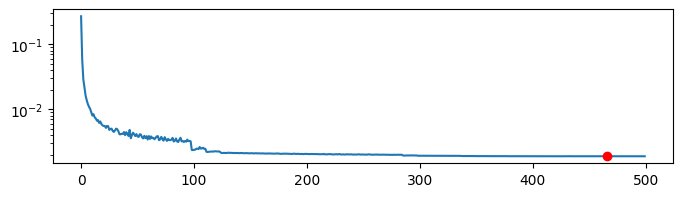

In [11]:
plt.figure(figsize=(8,2))
plt.plot(losses)
plt.yscale('log')
plt.scatter(best_epoch,losses[best_epoch], marker='o',c='red',zorder=2)
plt.show()

# Model vs. true trajectories

Recreates `figures/toggle-traj.ipynb` using the trained **unsplit** standard NODE
(`best_model-unsplit-20-20-20.pth`). For 16 random `(x0, u)` cases the model is integrated
with `torchode` and overlaid against the true toggle-switch dynamics. The integration
closure uses the unsplit forward `model(x, control(t))` (the split FTNODE used
`model(t, x, control)`). The figure is not saved.

In [12]:
plt.rcParams['font.family'] = 'serif'

# Load the trained unsplit standard NODE.
model_path = "best_model-unsplit-20-20-20.pth"

model = GeluSigmoidMLP(
    dims=[6, 20, 20, 20, 2],
    lower_bound=-10,
    upper_bound=8
)

model.load_state_dict(torch.load(model_path))
model.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [13]:
seed = 1234
# set_global_seed(seed = seed)

n_cases = 16
rng = np.random.default_rng(seed)

# idxs = rng.choice(len(dataset), size=n_cases, replace=False)

x1s = rng.uniform(low=0.0, high=6.0, size=n_cases)
x2s = rng.uniform(low=0.0, high=6.0, size=n_cases)

a1s = rng.uniform(low=0.0, high=5.0, size=n_cases)
a2s = rng.uniform(low=0.0, high=5.0, size=n_cases)

betas = rng.uniform(low=0.0, high=5.0, size=n_cases)
gammas = rng.uniform(low=0.0, high=5.0, size=n_cases)

X0s = np.vstack((x1s,x2s)).T
Us = np.vstack((a1s,a2s,betas,gammas)).T

XU = [(x0i,ui) for x0i, ui in zip(X0s,Us)]

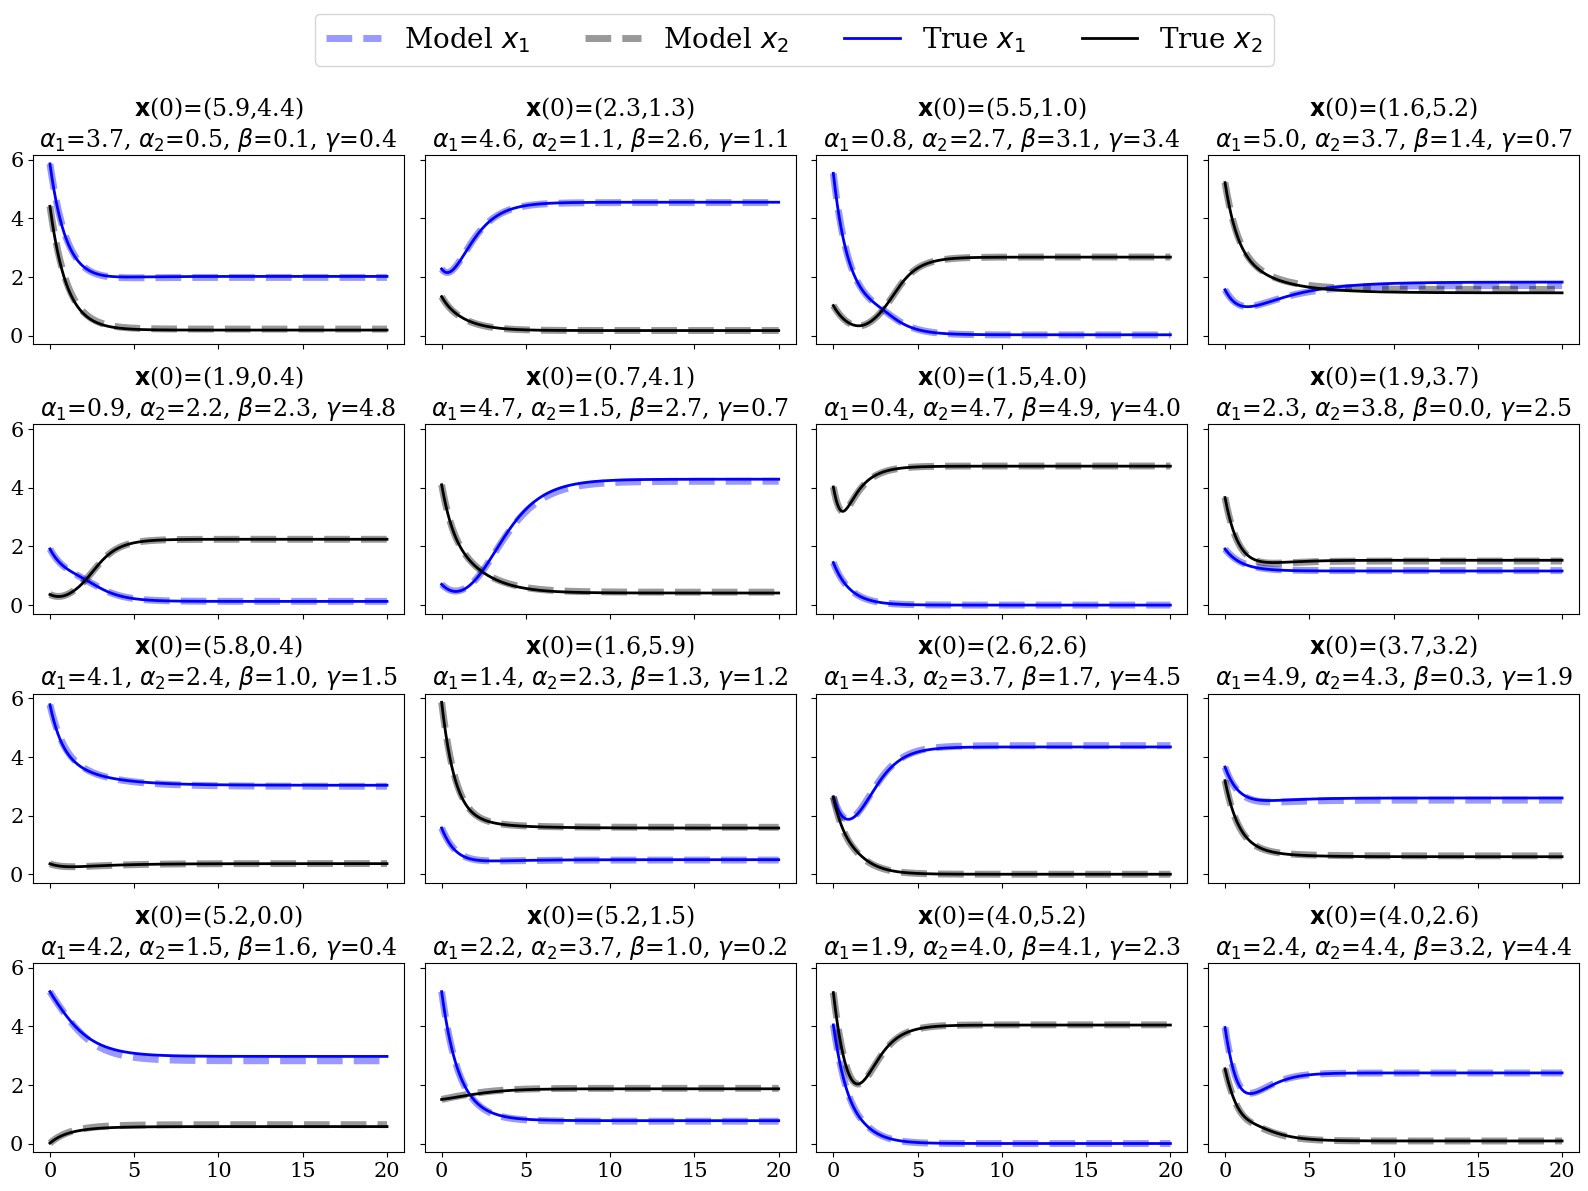

In [14]:
t_sim_max = 20


fig, axes = plt.subplots(4, 4, figsize=(16, 12),sharey=True, sharex=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):

    x0i, ui = XU[idx]

    ui_torch = torch.tensor(ui,dtype=torch.float32)
    x0i = torch.tensor(x0i,dtype=torch.float32).reshape(1, -1)

    with torch.no_grad():
        # Unsplit model: control must be 2D [batch, 4] for GeluSigmoidMLP forward(x, u).
        control = lambda t: ui_torch.unsqueeze(0)
        ti = torch.linspace(0, t_sim_max, 501, dtype=torch.float32)
        func = lambda t, x: model(x, control(t))

        sol_model = torchode.solve_ivp(
            f=func,
            y0=x0i,
            t_eval=ti,
            method='tsit5'
        )

    y_true = odeint(
        genetic_toggle_switch,
        x0i.numpy()[0],
        ti.numpy(),
        args=tuple(ui)
    )


    y_pred = sol_model.ys[0]

    ax.plot(ti, y_pred[:, 0], lw=5, alpha=0.4, linestyle='--', label=r"Model $x_1$", c='blue')
    ax.plot(ti, y_pred[:, 1], lw=5, alpha=0.4, linestyle='--', label=r"Model $x_2$", c='black')

    ax.plot(ti, y_true[:, 0], lw=2, c='blue', label=r"True $x_1$")
    ax.plot(ti, y_true[:, 1], lw=2, c='black', label=r"True $x_2$")

    
    x0 = x0i.numpy().flatten()
    ax.set_title(
        r"$\bf{x}$(0)="+f"({x0[0]:.1f},{x0[1]:.1f})"+"\n"
        rf"$\alpha_1$={ui[0]:.1f}, $\alpha_2$={ui[1]:.1f}, "
        rf"$\beta$={ui[2]:.1f}, $\gamma$={ui[3]:.1f}",
        fontsize=17
    )


for ax in axes.flatten():
    ax.tick_params(axis='both', which='major',labelsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4,fontsize=20)


plt.tight_layout(rect=[0, 0, 1, 0.93])
# Image intentionally not saved.
plt.show()